## 0. Business Understanding

### Background
Retention spend is finite. Discounting every customer destroys margin;
discounting none loses customers who would have stayed for a small
incentive. The value of a retention campaign depends entirely on
directing it at customers who will actually be worth keeping.

### Business Problem
An online retailer wants to identify high-value customers **before** the
value materialises, so marketing can act while those customers are still
active. This supports:

- Targeting retention offers at customers with high forward value
- Identifying valuable customers who are about to go quiet
- Setting acquisition spend against expected customer worth

### ML Objective
Build a **regression model** that predicts each customer's total spend in
a 16-week forward window, using only transaction behaviour observed
before that window opens.

### Success Criteria
- **Primary metric:** RMSE in pounds on a temporally held-out period
- **Secondary:** MAE, which is less distorted by a small number of
  wholesale customers, and R²
- **Baseline to beat:** "forward spend = previous-period spend". A model
  that cannot beat this adds nothing.
- **No temporal leakage:** every feature computed strictly before the cutoff date

### Model Validation Checks
- Train and CV scores within one standard deviation
- No leakage — all fitted transforms inside a pipeline, split on time not at random
- Residuals inspected across the value range, since errors on wholesale
  customers will dominate RMSE

In [67]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

df = pd.read_csv("EcommerceML.csv", encoding="latin1")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format="mixed")

print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


## 2. Data Understanding

**Source:** UCI Machine Learning Repository — Online Retail
**Origin:** UK-based online giftware retailer, non-store, 1 Dec 2010 – 9 Dec 2011
**Size:** 541,909 transaction lines × 8 columns
**Scale:** 4,372 customers | 4,070 products | 25,900 invoices | 38 countries
**Currency:** GBP

### Transaction identifiers
- **InvoiceNo** — 6-digit order number. *A `C` prefix marks a cancellation: 9,288 rows.*
- **StockCode** — product code. Some are administrative rather than products (`POST`, `M`, `BANK CHARGES`).

### Product
- **Description** — free-text product name, inconsistent capitalisation and spacing

### Quantity and price (continuous)
- **Quantity** — units per line. Range −80,995 to 80,995. *10,624 negative values are returns, mirrored by the positive purchase.*
- **UnitPrice** — price per unit in GBP. Range −11,062 to 38,970. *2,517 rows are zero or negative: adjustments, samples and write-offs, not sales.*

### Customer and geography
- **CustomerID** — customer number. *Missing in 135,080 rows (24.9%) — guest or unlinked checkouts. Cannot be used for customer-level modelling.*
- **Country** — heavily UK-dominated: 495,478 of 541,909 rows (91.4%). Germany, France and EIRE follow at under 2% each.

### Target
- **Not present in the raw data.** The target is constructed: total spend per customer within a forward time window, derived by aggregating `Quantity × UnitPrice` after a chosen cutoff date.

### Structure
One row per **line item**, not per customer. A single invoice spans multiple rows, and a customer holds multiple invoices. Customer-level modelling requires aggregation from 541,909 rows to roughly 4,300 (section 3.2). This is the principal difference from the credit project, where the data arrived one row per customer.

### Temporal structure and leakage
Transactions span 53 weeks. Because the target is **future** spend, the split must be on time rather than at random — a random split would allow features such as purchase frequency to include transactions from the prediction window, which is target leakage.

Additionally, 5,268 exact duplicate rows are present and will be removed before aggregation, since a duplicated line item would double a customer's measured spend.

## Data Exploration

In [69]:
df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [70]:
## Discrete: nominal
df["Country"].value_counts().head(10)

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

In [71]:
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

In [72]:
df["Country"].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

In [73]:
df["Country"].value_counts()

Country
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


In [74]:
# Share of rows and customers by country
pd.DataFrame({
    "rows": df["Country"].value_counts(),
    "pct_rows": (df["Country"].value_counts(normalize=True) * 100).round(2),
}).head(10)

,rows,pct_rows
Country,,
United Kingdom,495478,91.43
Germany,9495,1.75
France,8557,1.58
EIRE,8196,1.51
Spain,2533,0.47
Netherlands,2371,0.44
Belgium,2069,0.38
Switzerland,2002,0.37
Portugal,1519,0.28


In [75]:
# Administrative stock codes — not real products
df[df["StockCode"].astype(str).str.len() < 5]["StockCode"].value_counts().head(10)

StockCode
POST    1256
DOT      710
M        571
C2       144
D         77
S         63
CRUK      16
PADS       4
B          3
m          1
Name: count, dtype: int64

In [76]:
# Product and description cardinality
print("StockCode:", df["StockCode"].nunique())
print("Description:", df["Description"].nunique())
print("InvoiceNo:", df["InvoiceNo"].nunique())
print("CustomerID:", df["CustomerID"].nunique())

StockCode: 4070
Description: 4223
InvoiceNo: 25900
CustomerID: 4372


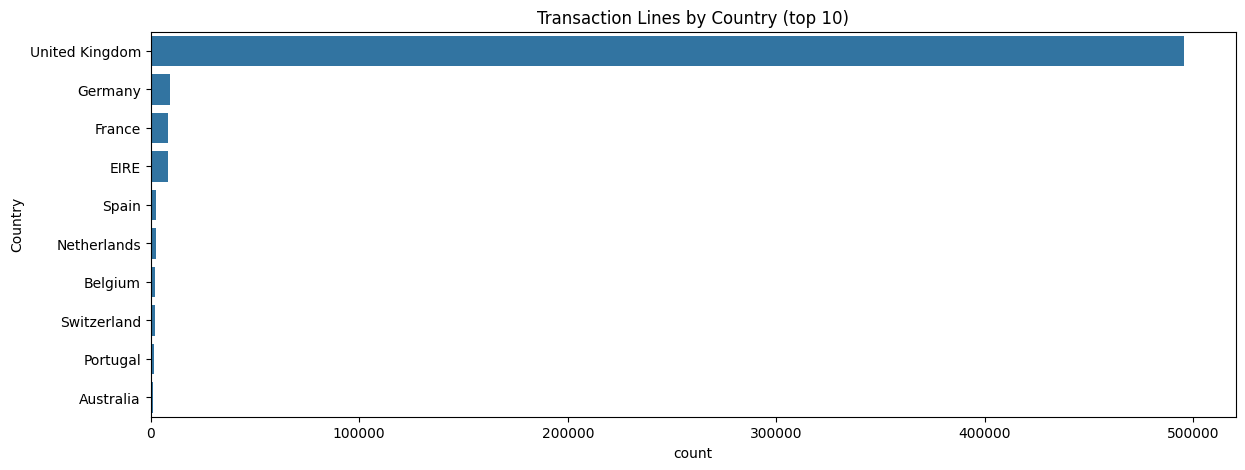

In [77]:
# Countplot for the top countries — the rest are too small to see
plt.rcParams["figure.figsize"] = (14, 5)
top = df["Country"].value_counts().head(10).index
sns.countplot(y=df[df["Country"].isin(top)]["Country"],
              order=top)
plt.title("Transaction Lines by Country (top 10)")
plt.show()

`Description` has 4,223 distinct values against 4,070 `StockCode` values,
so descriptions are inconsistent for the same product. `StockCode` is the
reliable product key. This does not affect customer-level aggregation but
would matter for any product-level analysis.

# Continuous

In [78]:
df[["Quantity", "UnitPrice"]].describe()

,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


In [79]:
df[["Quantity", "UnitPrice"]].skew()

Quantity      -0.264076
UnitPrice    186.506972
dtype: float64

### Findings

- `UnitPrice` skewness 186.5 — median £2.08 against a maximum of £38,970.
  The extreme tail is administrative rows, not product sales.
- `Quantity` skewness −0.26 is misleading: returns mirror purchases exactly
  (min −80,995, max +80,995), so the signs cancel. Skewness after filtering
  to completed sales will be strongly positive.
- 38 countries, but the UK accounts for 91.4% of rows. Country will be
  binned rather than one-hot encoded across all levels.
- Ten administrative stock codes identified (`POST`, `DOT`, `M`, `C2`, `D`,
  `S`, `CRUK`, `PADS`, `B`, `m`) covering postage, manual adjustments,
  samples and bank charges. Note `M` and `m` are the same code entered
  inconsistently.

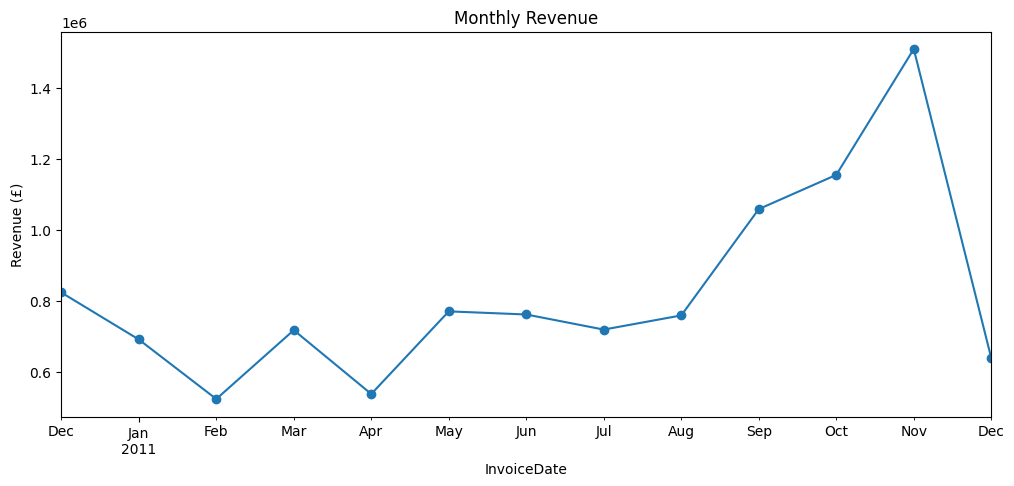

In [80]:
# Monthly revenue — determines where the cutoff date can sit
pos = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)].copy()
pos["Revenue"] = pos["Quantity"] * pos["UnitPrice"]
monthly = pos.set_index("InvoiceDate")["Revenue"].resample("ME").sum()

plt.rcParams["figure.figsize"] = (12, 5)
monthly.plot(marker="o")
plt.title("Monthly Revenue")
plt.ylabel("Revenue (£)")
plt.show()

In [81]:
monthly.round(0)

InvoiceDate
2010-12-31     823746.0
2011-01-31     691365.0
2011-02-28     523632.0
2011-03-31     717639.0
2011-04-30     537809.0
2011-05-31     770536.0
2011-06-30     761740.0
2011-07-31     719221.0
2011-08-31     759138.0
2011-09-30    1058590.0
2011-10-31    1154979.0
2011-11-30    1509496.0
2011-12-31     638793.0
Freq: ME, Name: Revenue, dtype: float64

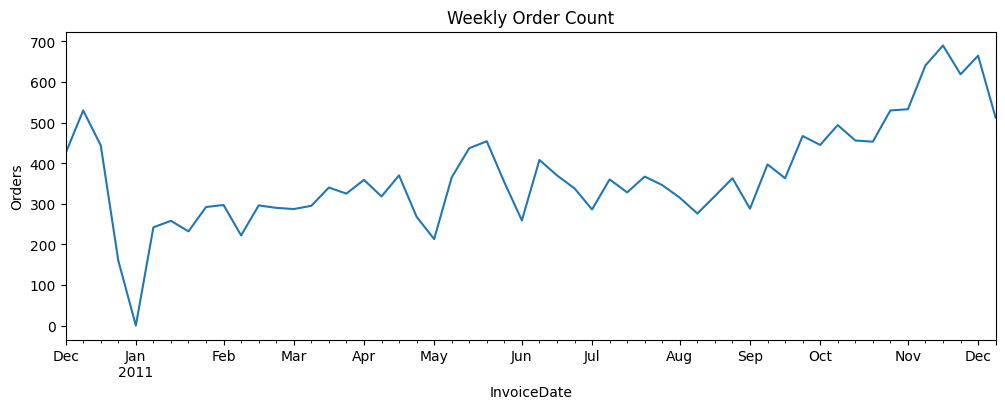

In [82]:
# Weekly order volume — checks the data is evenly distributed over time
weekly = pos.set_index("InvoiceDate")["InvoiceNo"].resample("W").nunique()
plt.rcParams["figure.figsize"] = (12, 4)
weekly.plot()
plt.title("Weekly Order Count")
plt.ylabel("Orders")
plt.show()

In [83]:
# How many customers are active in each half of the period?
mid = pd.Timestamp("2011-06-01")
before = set(pos[pos["InvoiceDate"] < mid]["CustomerID"].dropna())
after = set(pos[pos["InvoiceDate"] >= mid]["CustomerID"].dropna())
print(f"active before Jun 2011: {len(before):,}")
print(f"active after Jun 2011:  {len(after):,}")
print(f"active in both:         {len(before & after):,}")
print(f"only before (churned):  {len(before - after):,}")
print(f"only after (new):       {len(after - before):,}")

active before Jun 2011: 2,718
active after Jun 2011:  3,547
active in both:         1,927
only before (churned):  791
only after (new):       1,620


### 3.1 Cleaning

Stateless operations only — no statistic is learned from the data, so
these are safe to apply before aggregation and before the temporal split.

In [84]:
print("duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("after removing duplicates:", df.shape)

duplicate rows: 5268
after removing duplicates: (536641, 8)


In [85]:
# Invoice numbers starting 'C' are cancellations; negative quantities are returns
cancels = df["InvoiceNo"].astype(str).str.startswith("C")
print("cancellations:", cancels.sum())
print("negative quantity:", (df["Quantity"] < 0).sum())

df = df[~cancels]
df = df[df["Quantity"] > 0]
print("after removing cancellations and returns:", df.shape)

cancellations: 9251
negative quantity: 10587
after removing cancellations and returns: (526054, 8)


In [86]:
# Zero or negative unit price: adjustments, samples, write-offs — not sales
print("non-positive price:", (df["UnitPrice"] <= 0).sum())
df = df[df["UnitPrice"] > 0]
print("after removing non-positive prices:", df.shape)

non-positive price: 1176
after removing non-positive prices: (524878, 8)


Missing customer ID

In [87]:
# ~25% of rows are guest or unlinked checkouts. Real sales, but they cannot
# be attributed to a customer, so they are unusable for customer-level modelling.
print("missing CustomerID:", df["CustomerID"].isna().sum())
df = df[df["CustomerID"].notna()]
df["CustomerID"] = df["CustomerID"].astype(int)
print("after removing missing CustomerID:", df.shape)

missing CustomerID: 132186
after removing missing CustomerID: (392692, 8)


Revenue

In [88]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
print(f"total revenue: £{df['Revenue'].sum():,.0f}")
df.head()

total revenue: £8,887,209


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [89]:
print(f"customers: {df['CustomerID'].nunique():,}")
print(f"invoices: {df['InvoiceNo'].nunique():,}")
print(f"date range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")

customers: 4,338
invoices: 18,532
date range: 2010-12-01 to 2011-12-09


In [90]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64

In [91]:
print(f"rows: {len(df):,}")
print(f"customers: {df['CustomerID'].nunique():,}")
print(f"invoices: {df['InvoiceNo'].nunique():,}")
print(f"total revenue: £{df['Revenue'].sum():,.0f}")

rows: 392,692
customers: 4,338
invoices: 18,532
total revenue: £8,887,209


### 3.2 Customer Aggregation

The data is one row per line item. Customer-level modelling requires one
row per customer, so transactions are aggregated within a fixed
observation window, and the target is measured in a separate forward
window that no feature may touch.

In [92]:
CUTOFF = pd.Timestamp("2011-09-01")   # features from before this
END    = pd.Timestamp("2011-12-01")   # target measured up to here

observation = df[df["InvoiceDate"] < CUTOFF]
target_window = df[(df["InvoiceDate"] >= CUTOFF) & (df["InvoiceDate"] < END)]

print(f"observation: {observation['InvoiceDate'].min().date()} to {observation['InvoiceDate'].max().date()}  ({len(observation):,} rows)")
print(f"target:      {target_window['InvoiceDate'].min().date()} to {target_window['InvoiceDate'].max().date()}  ({len(target_window):,} rows)")

observation: 2010-12-01 to 2011-08-31  (224,036 rows)
target:      2011-09-01 to 2011-11-30  (151,630 rows)


In [93]:
# December 2011 is excluded entirely: the data stops on the 9th, so
# including a partial month would understate every customer's target.
print("rows dropped from Dec 2011:", (df["InvoiceDate"] >= END).sum())

rows dropped from Dec 2011: 17026


In [94]:
# Aggregate the observation window to one row per customer
snapshot = observation["InvoiceDate"].max()   # reference point for recency

customers = observation.groupby("CustomerID").agg(
    recency_days   = ("InvoiceDate", lambda x: (snapshot - x.max()).days),
    tenure_days    = ("InvoiceDate", lambda x: (snapshot - x.min()).days),
    frequency      = ("InvoiceNo", "nunique"),
    total_spend    = ("Revenue", "sum"),
    total_units    = ("Quantity", "sum"),
    n_products     = ("StockCode", "nunique"),
    n_lines        = ("Revenue", "size"),
    avg_unit_price = ("UnitPrice", "mean"),
    country        = ("Country", "first"),
)

print(customers.shape)
customers.head()

(3317, 9)


,recency_days,tenure_days,frequency,total_spend,total_units,n_products,n_lines,avg_unit_price,country
CustomerID,,,,,,,,,
12346,225,225,1,77183.60,74215,1,1,1.040000,United Kingdom
12347,29,267,5,2790.86,1590,82,124,2.797661,Iceland
12348,148,257,3,1487.24,2124,22,28,4.864643,Finland
12350,210,210,1,334.40,197,17,17,3.841176,Norway
12352,162,196,5,1561.81,254,26,38,27.449474,Norway


In [95]:
# Build the target: spend in the forward window, zero if they never returned
y = target_window.groupby("CustomerID")["Revenue"].sum()
customers["future_spend"] = customers.index.map(y).fillna(0.0)

print(f"customers: {len(customers):,}")
print(f"spent nothing in target window: {(customers['future_spend']==0).sum():,} "
      f"({(customers['future_spend']==0).mean():.1%})")
customers["future_spend"].describe().round(1)

customers: 3,317
spent nothing in target window: 1,446 (43.6%)


count      3317.0
mean        776.0
std        3926.9
min           0.0
25%           0.0
50%         170.6
75%         688.2
max      117634.5
Name: future_spend, dtype: float64

### Temporal design

| Window | Period | Length | Rows | Purpose |
|---|---|---|---|---|
| Observation | 2010-12-01 to 2011-08-31 | 39 weeks | 224,036 | Features |
| Target | 2011-09-01 to 2011-11-30 | 13 weeks | 151,630 | Label |
| Excluded | 2011-12-01 to 2011-12-09 | 9 days | 17,026 | Truncated month |

December 2011 is excluded entirely. The dataset ends on the 9th, so
including it would understate the target for any customer who would have
purchased later in the month.

Customers are defined by activity in the **observation** window. Those who
purchased before the cutoff and never returned receive a target of £0 —
they are the churned customers, roughly 44% of the population, and
excluding them would train the model on survivors only and cause
systematic overprediction.

`recency_days` is measured from the last date in the observation window
rather than from today, since the data is fifteen years old and every
customer would otherwise appear equally inactive.

**Leakage check:** no feature may reference a transaction dated on or
after the cutoff. Features are computed from `observation`, the target
from `target_window`, and the two dataframes never touch.

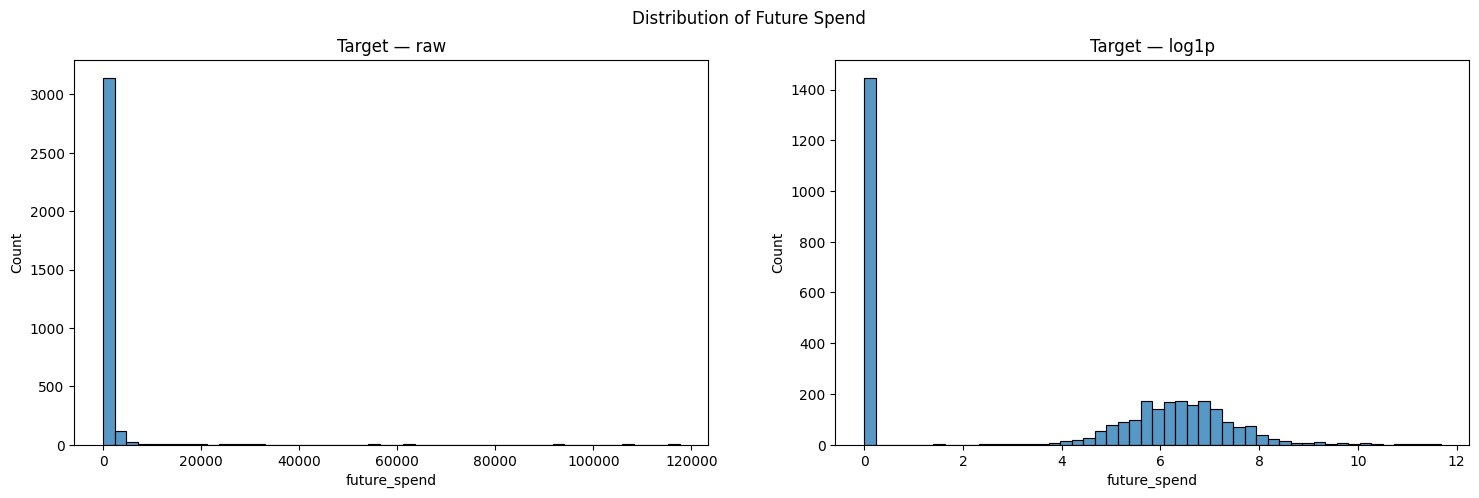

In [96]:
plt.rcParams["figure.figsize"] = (18, 5)
plt.subplot(1, 2, 1)
sns.histplot(customers["future_spend"], bins=50)
plt.title("Target — raw")
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(customers["future_spend"]), bins=50)
plt.title("Target — log1p")
plt.suptitle("Distribution of Future Spend")
plt.show()

In [97]:
print("skewness raw:", round(customers["future_spend"].skew(), 1))
print("skewness log1p:", round(np.log1p(customers["future_spend"]).skew(), 1))

skewness raw: 20.7
skewness log1p: -0.1


In [98]:
# Concentration — how much of forward revenue sits with how few customers
y = customers["future_spend"].sort_values(ascending=False)
for pct in [0.01, 0.05, 0.10, 0.20]:
    n = int(len(y) * pct)
    print(f"top {pct:.0%} ({n:>4} customers): {y.head(n).sum()/y.sum():.1%} of forward revenue")

top 1% (  33 customers): 34.8% of forward revenue
top 5% ( 165 customers): 54.2% of forward revenue
top 10% ( 331 customers): 66.5% of forward revenue
top 20% ( 663 customers): 81.1% of forward revenue


3.3 Feature Engineering

In [99]:
customers["avg_order_value"] = customers["total_spend"] / customers["frequency"]
customers["avg_basket_size"] = customers["total_units"] / customers["frequency"]
customers["lines_per_order"] = customers["n_lines"] / customers["frequency"]
customers["spend_per_day"]   = customers["total_spend"] / customers["tenure_days"].clip(lower=1)
customers["purchase_rate"]   = customers["frequency"] / customers["tenure_days"].clip(lower=1) * 30
customers["is_uk"]           = (customers["country"] == "United Kingdom").astype(int)
customers["single_purchase"] = (customers["frequency"] == 1).astype(int)

customers.head()

,recency_days,tenure_days,frequency,total_spend,total_units,n_products,n_lines,avg_unit_price,country,future_spend,avg_order_value,avg_basket_size,lines_per_order,spend_per_day,purchase_rate,is_uk,single_purchase
CustomerID,,,,,,,,,,,,,,,,,
12346,225,225,1,77183.60,74215,1,1,1.040000,United Kingdom,0.00,77183.600000,74215.0,1.000000,343.038222,0.133333,1,1
12347,29,267,5,2790.86,1590,82,124,2.797661,Iceland,1294.32,558.172000,318.0,24.800000,10.452659,0.561798,0,0
12348,148,257,3,1487.24,2124,22,28,4.864643,Finland,310.00,495.746667,708.0,9.333333,5.786926,0.350195,0,0
12350,210,210,1,334.40,197,17,17,3.841176,Norway,0.00,334.400000,197.0,17.000000,1.592381,0.142857,0,1
12352,162,196,5,1561.81,254,26,38,27.449474,Norway,944.23,312.362000,50.8,7.600000,7.968418,0.765306,0,0


In [100]:
# Which features carry signal?
num = customers.select_dtypes(include=np.number).drop(columns=["future_spend"])
num.corrwith(customers["future_spend"]).sort_values(key=abs, ascending=False).round(3)

total_spend        0.818
total_units        0.660
spend_per_day      0.608
frequency          0.449
n_lines            0.365
n_products         0.327
purchase_rate      0.212
recency_days      -0.131
avg_order_value    0.115
single_purchase   -0.109
tenure_days        0.104
avg_basket_size    0.058
is_uk             -0.056
lines_per_order    0.014
avg_unit_price    -0.002
dtype: float64

In [101]:
num.corrwith(np.log1p(customers["future_spend"])).sort_values(key=abs, ascending=False).round(3)

frequency          0.358
single_purchase   -0.351
n_products         0.351
recency_days      -0.340
n_lines            0.307
total_spend        0.238
total_units        0.218
tenure_days        0.181
spend_per_day      0.168
purchase_rate      0.116
lines_per_order    0.106
avg_unit_price    -0.041
is_uk             -0.033
avg_order_value    0.028
avg_basket_size    0.013
dtype: float64

### Feature signal

Correlations against the raw and log-transformed target rank almost
inversely:

| Feature | Raw target | log1p target |
|---|---|---|
| `total_spend` | 0.818 | 0.238 |
| `frequency` | 0.449 | 0.358 |
| `single_purchase` | −0.109 | −0.351 |
| `recency_days` | −0.131 | −0.340 |

The raw correlation is dominated by a small number of wholesale customers,
for whom prior spend is the strongest signal. On the log scale, where the
43.6% of customers with zero forward spend carry proportionate weight,
recency and single-purchase status become the strongest predictors.

These are two distinct questions — *will they return* and *how much will
they spend* — with different drivers. This motivates the two-stage
approach evaluated in section 5.

# 3.4 Wrangling Strategy

### 3.4 Wrangling Strategy

Transformation, scaling and encoding all learn parameters from the data
(a lambda, a mean and standard deviation, a category vocabulary), so they
are **decided here but executed inside the pipeline after the split**.

**Target transformation** — the target is modelled as `log1p(future_spend)`.
Raw skewness is 20.7 and 43.6% of values are exactly zero; `log1p` maps
zero to zero and compresses the wholesale tail. Predictions are inverted
with `expm1` before reporting, so all metrics are stated in pounds.

**Feature transformation** — Yeo-Johnson on the monetary and count
features, which share the target's skew. Box-Cox is unsuitable: several
engineered ratios can be zero.

**Scaling** — StandardScaler. Required for linear regression and KNN;
tree ensembles are unaffected but it is applied uniformly so all
candidates are compared under identical preprocessing.

**Encoding** — `country` has 38 levels with the UK at 91.4%, so one-hot
encoding all of them would create 37 near-empty columns. It is reduced to
the binary `is_uk` flag, already engineered in 3.3, and the raw `country`
column is dropped.

**Features excluded** — none on ethical grounds; this dataset contains no
protected characteristics. `avg_unit_price`, `lines_per_order`,
`is_uk` and `avg_basket_size` all correlate below 0.06 with the target and
are retained only so tree models can test for interactions.

# 4. Temporal Split

In [102]:
X = customers.drop(columns=["future_spend", "country"])
y = customers["future_spend"]

print(X.shape, y.shape)
print(X.columns.tolist())

(3317, 15) (3317,)
['recency_days', 'tenure_days', 'frequency', 'total_spend', 'total_units', 'n_products', 'n_lines', 'avg_unit_price', 'avg_order_value', 'avg_basket_size', 'lines_per_order', 'spend_per_day', 'purchase_rate', 'is_uk', 'single_purchase']


### Why there is no train_test_split

The temporal separation is already built in: features come from
2010-12-01 to 2011-08-31, the target from 2011-09-01 to 2011-11-30. No
feature can reference a transaction in the target window.

A second random split of the customer table is still needed to hold out
customers for evaluation. This is legitimate — customers are independent
of one another, and the temporal ordering is preserved for every customer
regardless of which side of the split they fall.

In [103]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(2653, 15) (664, 15)


In [104]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PowerTransformer

In [105]:
skewed = ["total_spend", "total_units", "avg_order_value", "avg_basket_size",
          "spend_per_day", "avg_unit_price", "n_lines", "n_products", "frequency"]

plain_numeric = ["recency_days", "tenure_days", "purchase_rate", "lines_per_order"]

binary = ["is_uk", "single_purchase"]

print(len(skewed + plain_numeric + binary), "vs", X_train.shape[1])

15 vs 15


In [106]:
preprocessor = ColumnTransformer([
    ("skew", PowerTransformer(method="yeo-johnson"), skewed),
    ("num", StandardScaler(), plain_numeric),
    ("bin", "passthrough", binary),
])

tmp = preprocessor.fit_transform(X_train)
print(tmp.shape)

(2653, 15)


# Target transformation

In [107]:
# Model in log space; invert with expm1 for reporting in pounds
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print("raw skew:", round(y_train.skew(), 1))
print("log skew:", round(y_train_log.skew(), 1))

raw skew: 18.3
log skew: -0.1


`log1p` reduces target skewness from 18.3 to −0.1, essentially symmetric.
The transform maps zero to zero, so the 43.6% of customers with no forward
spend are preserved at the bottom of the range rather than being distorted.
All metrics are reported in pounds after inverting with `expm1`.

In [108]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# "Forward spend equals prior spend" — the number every model must beat
baseline_pred = X_test["total_spend"]

print("BASELINE (forward spend = past spend)")
print(f"  RMSE: £{np.sqrt(mean_squared_error(y_test, baseline_pred)):,.0f}")
print(f"  MAE:  £{mean_absolute_error(y_test, baseline_pred):,.0f}")
print(f"  R²:   {r2_score(y_test, baseline_pred):.4f}")

BASELINE (forward spend = past spend)
  RMSE: £4,961
  MAE:  £1,239
  R²:   0.3978


In [109]:
# Scaled version — 39 weeks of history rescaled to a 13-week window
scaled_pred = X_test["total_spend"] * (13 / 39)

print("BASELINE (scaled to window length)")
print(f"  RMSE: £{np.sqrt(mean_squared_error(y_test, scaled_pred)):,.0f}")
print(f"  MAE:  £{mean_absolute_error(y_test, scaled_pred):,.0f}")
print(f"  R²:   {r2_score(y_test, scaled_pred):.4f}")

BASELINE (scaled to window length)
  RMSE: £4,480
  MAE:  £751
  R²:   0.5088


# 6. Modelling

In [110]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score

In [111]:
def evaluate(model, name):
    """Fit in log space, invert to pounds, report against the baseline."""
    model.fit(X_train, y_train_log)
    pred = np.expm1(model.predict(X_test))
    pred = np.clip(pred, 0, None)          # spend cannot be negative

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae  = mean_absolute_error(y_test, pred)
    r2   = r2_score(y_test, pred)
    print(f"{name}\n  RMSE: £{rmse:,.0f}   MAE: £{mae:,.0f}   R²: {r2:.4f}")
    return pred

In [112]:
# Linear Regression
lin = Pipeline([("prep", preprocessor), ("model", LinearRegression())])
lin.fit(X_train, y_train_log)

#Modelling and Evaluation
pred_train = np.clip(np.expm1(lin.predict(X_train)), 0, None)
print("Train R²:", r2_score(y_train, pred_train))
print("CV R² (log):", cross_val_score(lin, X_train, y_train_log, cv=5, scoring="r2").mean())

Train R²: 0.48175140704637043
CV R² (log): 0.2698734161118931


In [113]:
def scores(model, name):
    """Train and CV in log space, per the credit project structure.
    Test is reserved for section 7."""
    pred_train = model.predict(X_train)
    train_r2 = r2_score(y_train_log, pred_train)
    cv_r2 = cross_val_score(model, X_train, y_train_log, cv=5, scoring="r2").mean()
    cv_rmse = -cross_val_score(model, X_train, y_train_log, cv=5,
                               scoring="neg_root_mean_squared_error").mean()
    print(f"{name}")
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  CV R²:    {cv_r2:.4f}")
    print(f"  Gap:      {train_r2 - cv_r2:.4f}")
    print(f"  CV RMSE (log): {cv_rmse:.4f}")

In [114]:
from sklearn.preprocessing import PolynomialFeatures

poly_base = Pipeline([("prep", preprocessor),
                      ("poly", PolynomialFeatures(include_bias=False)),
                      ("model", LinearRegression())])

#Hyperparameter Tuning
param_grid = {"poly__degree": [2, 3]}
poly_grid = GridSearchCV(poly_base, param_grid, scoring="r2", cv=5, n_jobs=-1)
poly_grid.fit(X_train, y_train_log)

poly = poly_grid.best_estimator_
print(poly_grid.best_params_, round(poly_grid.best_score_, 4))

{'poly__degree': 2} 0.1668


In [115]:
def scores(model, name):
    """Train and CV in log space, per the credit project structure.
    Test is reserved for section 7."""
    pred_train = model.predict(X_train)
    train_r2 = r2_score(y_train_log, pred_train)
    cv_r2 = cross_val_score(model, X_train, y_train_log, cv=5, scoring="r2").mean()
    cv_rmse = -cross_val_score(model, X_train, y_train_log, cv=5,
                               scoring="neg_root_mean_squared_error").mean()
    print(f"{name}")
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  CV R²:    {cv_r2:.4f}")
    print(f"  Gap:      {train_r2 - cv_r2:.4f}")
    print(f"  CV RMSE (log): {cv_rmse:.4f}")

In [116]:
ridge_base = Pipeline([("prep", preprocessor), ("model", Ridge(random_state=42))])

#Hyperparameter Tuning
param_grid = {"model__alpha": [0.01, 0.1, 1, 10, 100, 1000]}
ridge_grid = GridSearchCV(ridge_base, param_grid, scoring="r2", cv=5, n_jobs=-1)
ridge_grid.fit(X_train, y_train_log)

ridge = ridge_grid.best_estimator_
print(ridge_grid.best_params_, round(ridge_grid.best_score_, 4))

{'model__alpha': 1} 0.2704


In [117]:
def scores(model, name):
    """Train and CV in log space, per the credit project structure.
    Test is reserved for section 7."""
    pred_train = model.predict(X_train)
    train_r2 = r2_score(y_train_log, pred_train)
    cv_r2 = cross_val_score(model, X_train, y_train_log, cv=5, scoring="r2").mean()
    cv_rmse = -cross_val_score(model, X_train, y_train_log, cv=5,
                               scoring="neg_root_mean_squared_error").mean()
    print(f"{name}")
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  CV R²:    {cv_r2:.4f}")
    print(f"  Gap:      {train_r2 - cv_r2:.4f}")
    print(f"  CV RMSE (log): {cv_rmse:.4f}")

In [118]:
from sklearn.linear_model import Lasso

lasso_base = Pipeline([("prep", preprocessor), ("model", Lasso(random_state=42, max_iter=5000))])

#Hyperparameter Tuning
param_grid = {"model__alpha": [0.001, 0.01, 0.1, 1, 10]}
lasso_grid = GridSearchCV(lasso_base, param_grid, scoring="r2", cv=5, n_jobs=-1)
lasso_grid.fit(X_train, y_train_log)

lasso = lasso_grid.best_estimator_
print(lasso_grid.best_params_, round(lasso_grid.best_score_, 4))

#Important features — Lasso zeroes out weak predictors
coef = pd.Series(lasso.named_steps["model"].coef_,
                 index=lasso.named_steps["prep"].get_feature_names_out())
print(f"\nfeatures kept: {(coef != 0).sum()} of {len(coef)}")
coef[coef != 0].sort_values(key=abs, ascending=False).round(4)

{'model__alpha': 0.001} 0.2699

features kept: 15 of 15


skew__total_units        1.8981
skew__total_spend       -1.7719
skew__avg_order_value    1.5294
skew__avg_basket_size   -1.4521
skew__frequency          1.1899
bin__single_purchase     1.1357
skew__n_lines            0.9517
skew__n_products        -0.4620
num__recency_days       -0.4296
num__tenure_days         0.2334
skew__avg_unit_price    -0.2111
skew__spend_per_day      0.1733
bin__is_uk              -0.1452
num__lines_per_order    -0.0859
num__purchase_rate       0.0498
dtype: float64

In [119]:
def scores(model, name):
    """Train and CV in log space, per the credit project structure.
    Test is reserved for section 7."""
    pred_train = model.predict(X_train)
    train_r2 = r2_score(y_train_log, pred_train)
    cv_r2 = cross_val_score(model, X_train, y_train_log, cv=5, scoring="r2").mean()
    cv_rmse = -cross_val_score(model, X_train, y_train_log, cv=5,
                               scoring="neg_root_mean_squared_error").mean()
    print(f"{name}")
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  CV R²:    {cv_r2:.4f}")
    print(f"  Gap:      {train_r2 - cv_r2:.4f}")
    print(f"  CV RMSE (log): {cv_rmse:.4f}")

In [120]:
from sklearn.linear_model import ElasticNet

en_base = Pipeline([("prep", preprocessor), ("model", ElasticNet(random_state=42, max_iter=5000))])

#Hyperparameter Tuning
param_grid = {"model__alpha": [0.001, 0.01, 0.1, 1],
              "model__l1_ratio": [0.1, 0.5, 0.9]}
en_grid = GridSearchCV(en_base, param_grid, scoring="r2", cv=5, n_jobs=-1)
en_grid.fit(X_train, y_train_log)

en = en_grid.best_estimator_
print(en_grid.best_params_, round(en_grid.best_score_, 4))

{'model__alpha': 0.001, 'model__l1_ratio': 0.1} 0.2704


In [121]:
def scores(model, name):
    """Train and CV in log space, per the credit project structure.
    Test is reserved for section 7."""
    pred_train = model.predict(X_train)
    train_r2 = r2_score(y_train_log, pred_train)
    cv_r2 = cross_val_score(model, X_train, y_train_log, cv=5, scoring="r2").mean()
    cv_rmse = -cross_val_score(model, X_train, y_train_log, cv=5,
                               scoring="neg_root_mean_squared_error").mean()
    print(f"{name}")
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  CV R²:    {cv_r2:.4f}")
    print(f"  Gap:      {train_r2 - cv_r2:.4f}")
    print(f"  CV RMSE (log): {cv_rmse:.4f}")

In [122]:
scores(lin, "Linear")
scores(poly, "Polynomial")
scores(ridge, "Ridge")
scores(lasso, "Lasso")
scores(en, "ElasticNet")

Linear
  Train R²: 0.2836
  CV R²:    0.2699
  Gap:      0.0137
  CV RMSE (log): 2.8005
Polynomial
  Train R²: 0.3361
  CV R²:    0.1668
  Gap:      0.1693
  CV RMSE (log): 2.9875
Ridge
  Train R²: 0.2834
  CV R²:    0.2704
  Gap:      0.0130
  CV RMSE (log): 2.7996
Lasso
  Train R²: 0.2833
  CV R²:    0.2699
  Gap:      0.0134
  CV RMSE (log): 2.8006
ElasticNet
  Train R²: 0.2830
  CV R²:    0.2704
  Gap:      0.0126
  CV RMSE (log): 2.7995


In [123]:
X_train[["total_spend","total_units","avg_order_value","avg_basket_size","frequency"]].corr().round(2)

,total_spend,total_units,avg_order_value,avg_basket_size,frequency
total_spend,1.00,0.95,0.43,0.39,0.60
total_units,0.95,1.00,0.33,0.45,0.55
avg_order_value,0.43,0.33,1.00,0.69,0.08
avg_basket_size,0.39,0.45,0.69,1.00,0.09
frequency,0.60,0.55,0.08,0.09,1.00


In [124]:
import time

models = [("Linear", lin), ("Ridge", ridge), ("Lasso", lasso), ("ElasticNet", en)]

for name, m in models:
    t0 = time.time()
    m.fit(X_train, y_train_log)
    fit_time = time.time() - t0

    t0 = time.time()
    for _ in range(100):
        m.predict(X_test)
    pred_time = (time.time() - t0) / 100 * 1000

    print(f"{name:12s} fit {fit_time*1000:>7.1f} ms   predict {pred_time:>6.2f} ms")

Linear       fit    55.1 ms   predict   6.48 ms
Ridge        fit    79.6 ms   predict   7.56 ms
Lasso        fit   127.2 ms   predict   6.39 ms
ElasticNet   fit    91.1 ms   predict   4.87 ms


In [125]:
# Random Forest Regressor
rf_base = Pipeline([("prep", preprocessor),
                    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))])

#Hyperparameter Tuning
param_grid = {"model__n_estimators": [200, 300],
              "model__max_depth": [4, 6, 10, None],
              "model__min_samples_leaf": [1, 5, 20]}

rf_grid = GridSearchCV(rf_base, param_grid, scoring="r2", cv=5)
rf_grid.fit(X_train, y_train_log)

rf = rf_grid.best_estimator_
print(rf_grid.best_params_, round(rf_grid.best_score_, 4))

{'model__max_depth': 4, 'model__min_samples_leaf': 5, 'model__n_estimators': 200} 0.2779


In [126]:
#Important features
feats_rf = pd.DataFrame(data=rf.named_steps["model"].feature_importances_,
                        index=rf.named_steps["prep"].get_feature_names_out(),
                        columns=["Importance"])
feats_rf.sort_values("Importance", ascending=False).head(15)

,Importance
skew__total_spend,0.471726
skew__total_units,0.148346
skew__frequency,0.145270
num__recency_days,0.056234
skew__avg_unit_price,0.034028
skew__spend_per_day,0.033776
skew__n_lines,0.030915
num__purchase_rate,0.021077
skew__avg_order_value,0.019893
num__tenure_days,0.011424


In [127]:
#Modelling and Evaluation
scores(rf, "Random Forest")

Random Forest
  Train R²: 0.3395
  CV R²:    0.2779
  Gap:      0.0616
  CV RMSE (log): 2.7850


In [128]:
# Gradient Boosting Regressor
model = GradientBoostingRegressor(random_state=42)
gb_base = Pipeline([("prep", preprocessor), ("model", model)])

#Hyperparameter Tuning
param_grid = {"model__n_estimators": [100, 200],
              "model__learning_rate": [0.05, 0.1],
              "model__max_depth": [2, 3, 5]}

gb_grid = GridSearchCV(gb_base, param_grid, scoring="r2", cv=5, n_jobs=-1)
gb_grid.fit(X_train, y_train_log)

gb = gb_grid.best_estimator_
print(gb_grid.best_params_)
print("Best CV R²:", gb_grid.best_score_)

{'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 100}
Best CV R²: 0.2753233333638308


In [129]:
scores(gb, "Gradient Boosting")

Gradient Boosting
  Train R²: 0.3294
  CV R²:    0.2753
  Gap:      0.0541
  CV RMSE (log): 2.7901


In [130]:
# XGBoost Regressor
model = XGBRegressor(random_state=42)
xgb_base = Pipeline([("prep", preprocessor), ("model", model)])

In [132]:
#Hyperparameter Tuning
param_grid = {"model__n_estimators": [100, 200],
              "model__max_depth": [2, 3, 5],
              "model__learning_rate": [0.05, 0.1],
              "model__gamma": [0, 0.3]}

xgb_grid = GridSearchCV(xgb_base, param_grid, scoring="r2", cv=5, n_jobs=-1)
xgb_grid.fit(X_train, y_train_log)

xgb = xgb_grid.best_estimator_
print(xgb_grid.best_params_)
print("Best CV R²:", xgb_grid.best_score_)

{'model__gamma': 0.3, 'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 100}
Best CV R²: 0.2756578976325823


In [133]:
#Important features
feats_xgb = pd.DataFrame(data=xgb.named_steps["model"].feature_importances_,
                         index=xgb.named_steps["prep"].get_feature_names_out(),
                         columns=["Importance"])
feats_xgb.sort_values("Importance", ascending=False).head(15)

,Importance
skew__total_spend,0.281568
skew__frequency,0.229012
skew__total_units,0.189345
skew__n_lines,0.069167
num__recency_days,0.049406
skew__spend_per_day,0.047252
skew__avg_unit_price,0.022732
num__purchase_rate,0.019347
skew__avg_order_value,0.018431
num__lines_per_order,0.016598


In [134]:
#Modelling and Evaluation
scores(xgb, "XGBoost")

XGBoost
  Train R²: 0.3253
  CV R²:    0.2757
  Gap:      0.0497
  CV RMSE (log): 2.7894


In [135]:
# KNN Regressor
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor()
knn_base = Pipeline([("prep", preprocessor), ("model", model)])

#Hyperparameter Tuning
param_grid = {"model__n_neighbors": [5, 15, 31, 51],
              "model__p": [1, 2]}

knn_grid = GridSearchCV(knn_base, param_grid, scoring="r2", cv=5, n_jobs=-1)
knn_grid.fit(X_train, y_train_log)

knn = knn_grid.best_estimator_
print(knn_grid.best_params_)
print("Best CV R²:", knn_grid.best_score_)

{'model__n_neighbors': 51, 'model__p': 2}
Best CV R²: 0.2679828124790223


In [136]:
scores(knn, "KNN")

KNN
  Train R²: 0.2995
  CV R²:    0.2680
  Gap:      0.0315
  CV RMSE (log): 2.8044


In [138]:
# Decision Tree Regressor
model = DecisionTreeRegressor(random_state=42)
dt_base = Pipeline([("prep", preprocessor), ("model", model)])
dt_base.fit(X_train, y_train_log)
print("Unbounded depth:", dt_base.named_steps["model"].get_depth())

Unbounded depth: 29


In [139]:
#Hyperparameter Tuning
param_grid = {"model__max_depth": list(range(2, 15)),
              "model__min_samples_leaf": [1, 5, 20, 50]}

dt_grid = GridSearchCV(dt_base, param_grid, scoring="r2", cv=5, n_jobs=-1)
dt_grid.fit(X_train, y_train_log)

dt = dt_grid.best_estimator_
print(dt_grid.best_params_)
print("Best CV R²:", dt_grid.best_score_)

{'model__max_depth': 5, 'model__min_samples_leaf': 50}
Best CV R²: 0.23684000654273368


In [140]:
#Important features
feats_dt = pd.DataFrame(data=dt.named_steps["model"].feature_importances_,
                        index=dt.named_steps["prep"].get_feature_names_out(),
                        columns=["Importance"])
feats_dt.sort_values("Importance", ascending=False).head(15)

,Importance
skew__total_spend,0.638653
skew__frequency,0.146693
skew__spend_per_day,0.052750
num__recency_days,0.038976
skew__total_units,0.029037
skew__avg_unit_price,0.028780
bin__single_purchase,0.019043
skew__n_products,0.014688
skew__n_lines,0.009935
skew__avg_basket_size,0.008748


In [141]:
#Modelling and Evaluation
scores(dt, "Decision Tree")

Decision Tree
  Train R²: 0.3177
  CV R²:    0.2368
  Gap:      0.0809
  CV RMSE (log): 2.8634


In [142]:
results = []
for name, m in [("Linear", lin), ("Polynomial", poly), ("Ridge", ridge),
                ("Lasso", lasso), ("ElasticNet", en), ("Decision Tree", dt),
                ("Random Forest", rf), ("Gradient Boosting", gb),
                ("XGBoost", xgb), ("KNN", knn)]:
    s = cross_val_score(m, X_train, y_train_log, cv=5, scoring="r2")
    train_r2 = r2_score(y_train_log, m.predict(X_train))
    results.append({"model": name, "train_r2": round(train_r2, 4),
                    "cv_r2": round(s.mean(), 4), "cv_std": round(s.std(), 4),
                    "gap": round(train_r2 - s.mean(), 4)})

pd.DataFrame(results).sort_values("cv_r2", ascending=False)

,model,train_r2,cv_r2,cv_std,gap
6,Random Forest,0.3395,0.2779,0.0381,0.0616
8,XGBoost,0.3253,0.2757,0.0376,0.0497
7,Gradient Boosting,0.3294,0.2753,0.0364,0.0541
2,Ridge,0.2834,0.2704,0.0358,0.0130
4,ElasticNet,0.2830,0.2704,0.0355,0.0126
0,Linear,0.2836,0.2699,0.0366,0.0137
3,Lasso,0.2833,0.2699,0.0358,0.0134
9,KNN,0.2995,0.2680,0.0317,0.0315
5,Decision Tree,0.3177,0.2368,0.0337,0.0809
1,Polynomial,0.3361,0.1668,0.0934,0.1693


### Model comparison

| Model | Train R² | CV R² | CV std | Gap |
|---|---|---|---|---|
| Random Forest | 0.3395 | 0.2779 | 0.0381 | 0.0616 |
| XGBoost | 0.3253 | 0.2757 | 0.0376 | 0.0497 |
| Gradient Boosting | 0.3294 | 0.2753 | 0.0364 | 0.0541 |
| Ridge | 0.2834 | 0.2704 | 0.0358 | 0.0130 |
| ElasticNet | 0.2830 | 0.2704 | 0.0355 | 0.0126 |
| Linear | 0.2836 | 0.2699 | 0.0366 | 0.0137 |
| Lasso | 0.2833 | 0.2699 | 0.0358 | 0.0134 |
| KNN | 0.2995 | 0.2680 | 0.0317 | 0.0315 |
| Decision Tree | 0.3177 | 0.2368 | 0.0337 | 0.0809 |
| Polynomial | 0.3361 | 0.1668 | 0.0934 | 0.1693 |

Eight of ten specifications fall between CV R² 0.268 and 0.278 — a spread
of 0.010 against fold standard deviations of ~0.036. The ranking among
them is not statistically meaningful.

The two exceptions are the single decision tree (0.237) and polynomial
expansion (0.167), both with the largest train–CV gaps. Polynomial's gap
of 0.169 and elevated fold variance (0.093) make it the clearest case of
overfitting.

**Ridge regression is selected.** It matches the best CV score within
noise while carrying a train–CV gap of 0.013 against Random Forest's
0.062, is the fastest to fit and predict, and its behaviour is
straightforward to explain. Where cross-validation cannot distinguish
models, the simplest specification is preferred.

The convergence across six model families indicates the ceiling is set by
the information available in the features rather than by algorithm choice.

In [143]:
final = ridge
pred = np.clip(np.expm1(final.predict(X_test)), 0, None)

print("RIDGE — test set (single evaluation)")
print(f"  RMSE: £{np.sqrt(mean_squared_error(y_test, pred)):,.0f}")
print(f"  MAE:  £{mean_absolute_error(y_test, pred):,.0f}")
print(f"  R²:   {r2_score(y_test, pred):.4f}")
print()
print("BASELINE (past spend scaled to window)")
print(f"  RMSE: £4,480   MAE: £751   R²: 0.5088")

RIDGE — test set (single evaluation)
  RMSE: £5,521
  MAE:  £828
  R²:   0.2541

BASELINE (past spend scaled to window)
  RMSE: £4,480   MAE: £751   R²: 0.5088


In [144]:
ridge_raw = Pipeline([("prep", preprocessor), ("model", Ridge(alpha=0.001, random_state=42))])
ridge_raw.fit(X_train, y_train)          # raw target, not log
pred_raw = np.clip(ridge_raw.predict(X_test), 0, None)
print(f"RMSE: £{np.sqrt(mean_squared_error(y_test, pred_raw)):,.0f}")
print(f"MAE:  £{mean_absolute_error(y_test, pred_raw):,.0f}")
print(f"R²:   {r2_score(y_test, pred_raw):.4f}")

RMSE: £5,812
MAE:  £1,059
R²:   0.1733


In [145]:
rf_raw = Pipeline([("prep", preprocessor),
                   ("model", RandomForestRegressor(n_estimators=200, max_depth=4,
                                                   min_samples_leaf=5,
                                                   random_state=42, n_jobs=-1))])
rf_raw.fit(X_train, y_train)
pred_rf = np.clip(rf_raw.predict(X_test), 0, None)
print(f"RMSE: £{np.sqrt(mean_squared_error(y_test, pred_rf)):,.0f}")
print(f"MAE:  £{mean_absolute_error(y_test, pred_rf):,.0f}")
print(f"R²:   {r2_score(y_test, pred_rf):.4f}")

RMSE: £4,757
MAE:  £850
R²:   0.4462


In [146]:
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

# Target: did the customer buy anything in the forward window?
churn_train = (y_train > 0).astype(int)
churn_test = (y_test > 0).astype(int)
print(f"returned: {churn_train.mean():.1%} of training customers")

returned: 56.2% of training customers


In [148]:
from sklearn.linear_model import LogisticRegression
clf_base = Pipeline([("prep", preprocessor),
                     ("model", LogisticRegression(max_iter=2000, random_state=42))])

#Hyperparameter Tuning
param_grid = {"model__C": [0.01, 0.1, 1, 10]}
clf_grid = GridSearchCV(clf_base, param_grid, scoring="roc_auc", cv=5, n_jobs=-1)
clf_grid.fit(X_train, churn_train)

clf = clf_grid.best_estimator_
print(clf_grid.best_params_)
print("Best CV ROC AUC:", clf_grid.best_score_)

{'model__C': 0.01}
Best CV ROC AUC: 0.7494979067478896


In [149]:
#Modelling and Evaluation — test set, single evaluation
probs = clf.predict_proba(X_test)[:, 1]
print("ROC AUC:", round(roc_auc_score(churn_test, probs), 4))
print("Avg precision:", round(average_precision_score(churn_test, probs), 4))
print(f"Base rate: {churn_test.mean():.1%}\n")
print(classification_report(churn_test, (probs >= 0.5).astype(int),
                            target_names=["did not return", "returned"]))

ROC AUC: 0.7313
Avg precision: 0.8014
Base rate: 57.1%

                precision    recall  f1-score   support

did not return       0.63      0.60      0.61       285
      returned       0.71      0.73      0.72       379

      accuracy                           0.67       664
     macro avg       0.67      0.67      0.67       664
  weighted avg       0.67      0.67      0.67       664



In [150]:
# Business framing: how well does it find customers about to lapse?
at_risk = pd.DataFrame({"prob_return": probs, "spend": y_test.values},
                       index=X_test.index).sort_values("prob_return")

for pct in [0.10, 0.20, 0.30]:
    n = int(len(at_risk) * pct)
    grp = at_risk.head(n)
    print(f"lowest {pct:.0%} by return probability ({n} customers): "
          f"{(grp['spend'] > 0).mean():.1%} actually returned "
          f"(overall {(y_test > 0).mean():.1%})")

lowest 10% by return probability (66 customers): 31.8% actually returned (overall 57.1%)
lowest 20% by return probability (132 customers): 36.4% actually returned (overall 57.1%)
lowest 30% by return probability (199 customers): 35.7% actually returned (overall 57.1%)


### Churn classification

While forward *spend* cannot be predicted better than a naive baseline,
whether a customer returns at all is predictable. Logistic regression on
the same features achieves ROC AUC 0.7313 and average precision 0.8014
against a 57.1% base rate, with accuracy of 67% against a majority-class
baseline of 57.1%.

The practical value is in the tail. Of the 66 customers ranked least
likely to return, 31.8% did — against 57.1% overall, so a campaign
targeting that decile reaches customers roughly 1.8× more likely to
lapse than a random selection. The advantage narrows at wider targeting
(36.4% at 20%, 35.7% at 30%), so the model supports a focused retention
campaign rather than a broad one.

**This is the project's usable output.** The data supports "who is about
to leave" but not "how much will they spend" — a distinction that only
becomes visible when the regression is benchmarked against a naive
baseline.

In [151]:
import joblib, json, sklearn

joblib.dump(clf, "churn_model.pkl")

metadata = {
    "model_type": "LogisticRegression",
    "task": "will customer purchase in forward window",
    "observation_window": "2010-12-01 to 2011-08-31",
    "target_window": "2011-09-01 to 2011-11-30",
    "test_roc_auc": 0.7313,
    "test_average_precision": 0.8014,
    "base_rate": 0.571,
    "regression_finding": "no model beat baseline (RMSE £4,480, R² 0.5088)",
    "sklearn_version": sklearn.__version__,
}
json.dump(metadata, open("clv_metadata.json", "w"), indent=2)
print("saved")

saved
